In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n── First 5 rows ──")
display(df.head())

print("\n── Data Types & Missing Values ──")
missing = pd.DataFrame({
    'dtype':   df.dtypes,
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing)

Dataset loaded: 891 rows × 12 columns

── First 5 rows ──


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



── Data Types & Missing Values ──


,dtype,missing,missing%
PassengerId,int64,0,0.00
Survived,int64,0,0.00
Pclass,int64,0,0.00
Name,object,0,0.00
Sex,object,0,0.00
Age,float64,177,19.87
SibSp,int64,0,0.00
Parch,int64,0,0.00
Ticket,object,0,0.00
Fare,float64,0,0.00


In [9]:
# ─────────────────────────────────────────────
# CELL 3 — Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'text.color':       '#e0e0e0',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#a0a0a0',
    'ytick.color':      '#a0a0a0',
    'axes.edgecolor':   '#333344',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'grid.color':       '#2a2d3a',
    'grid.alpha':        0.5,
})


plt.tight_layout()
plt.show()
print(" EDA complete!")
display()

<Figure size 640x480 with 0 Axes>

 EDA complete!


In [10]:
# ─────────────────────────────────────────────
# CELL 4 — Feature Engineering
# ─────────────────────────────────────────────
def engineer_features(df):
    df = df.copy()

    # Extract Title from passenger name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr',
         'Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Family size & alone flag
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

    # Fill missing Age with median per Title group
    df['Age'] = df.groupby('Title')['Age'].transform(
        lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # Age & Fare bands
    df['AgeBand']  = pd.cut(df['Age'],  bins=[0,12,20,40,60,81],
                            labels=[0,1,2,3,4]).astype(int)
    df['Fare']     = df['Fare'].fillna(df['Fare'].median())
    df['FareBand'] = pd.qcut(df['Fare'], 4, labels=[0,1,2,3]).astype(int)

    # Cabin presence
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    # Fill missing Embarked
    df['Embarked'] = df['Embarked'].fillna('S')

    # Encode categorical columns
    le = LabelEncoder()
    for col in ['Sex', 'Embarked', 'Title']:
        df[col] = le.fit_transform(df[col])

    return df

df_eng = engineer_features(df)

FEATURES = ['Pclass', 'Sex', 'AgeBand', 'FareBand', 'Embarked',
            'FamilySize', 'IsAlone', 'HasCabin', 'Title', 'SibSp', 'Parch']

print("Feature engineering complete!")
print(f"\nFeatures used ({len(FEATURES)}): {FEATURES}")
display(df_eng[FEATURES].head())

Feature engineering complete!

Features used (11): ['Pclass', 'Sex', 'AgeBand', 'FareBand', 'Embarked', 'FamilySize', 'IsAlone', 'HasCabin', 'Title', 'SibSp', 'Parch']


,Pclass,Sex,AgeBand,FareBand,Embarked,FamilySize,IsAlone,HasCabin,Title,SibSp,Parch
0,3,1,2,0,2,2,0,0,2,1,0
1,1,0,2,3,0,2,0,1,3,1,0
2,3,0,2,1,2,1,1,0,1,0,0
3,1,0,2,3,2,2,0,1,3,1,0
4,3,1,2,1,2,1,1,0,2,0,0


In [11]:
# ─────────────────────────────────────────────
# CELL 5 — Train / Test Split & Scaling
# ─────────────────────────────────────────────
X = df_eng[FEATURES]
y = df_eng['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f" Split complete!")
print(f"   Train : {X_train.shape[0]} samples")
print(f"   Test  : {X_test.shape[0]} samples")
print(f"   Survived in train: {y_train.mean():.2%}")
print(f"   Survived in test : {y_test.mean():.2%}")

 Split complete!
   Train : 712 samples
   Test  : 179 samples
   Survived in train: 38.34%
   Survived in test : 38.55%


In [12]:
# ─────────────────────────────────────────────
# CELL 6 — Train All Models
# ─────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6,
                                                   random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                       learning_rate=0.05,
                                                       random_state=42),
    'SVM':                 SVC(probability=True, kernel='rbf', C=1.0, random_state=42),
}

# Models that need scaled features
NEEDS_SCALE = {'Logistic Regression', 'SVM'}

results = {}
print("Training models...\n")
print(f"{'Model':<24} {'Accuracy':>10} {'ROC-AUC':>10} {'CV Mean':>10} {'CV Std':>8}")
print("─" * 66)

for name, model in models.items():
    Xtr = X_train_sc if name in NEEDS_SCALE else X_train
    Xte = X_test_sc  if name in NEEDS_SCALE else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    cv    = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'model':    model,
        'preds':    preds,
        'proba':    proba,
        'acc':      accuracy_score(y_test, preds),
        'roc':      roc_auc_score(y_test, proba),
        'cv_mean':  cv.mean(),
        'cv_std':   cv.std(),
    }
    r = results[name]
    print(f"{name:<24} {r['acc']:>10.4f} {r['roc']:>10.4f} "
          f"{r['cv_mean']:>10.4f} {r['cv_std']:>8.4f}")

best_name = max(results, key=lambda k: results[k]['acc'])
best      = results[best_name]
print(f"\n🏆 Best model: {best_name}  "
      f"(Accuracy = {best['acc']:.2%}, ROC-AUC = {best['roc']:.4f})")

Training models...

Model                      Accuracy    ROC-AUC    CV Mean   CV Std
──────────────────────────────────────────────────────────────────
Logistic Regression          0.8045     0.8584     0.7978   0.0199
Random Forest                0.8101     0.8567     0.8090   0.0169
Gradient Boosting            0.7765     0.8490     0.8329   0.0179
SVM                          0.8212     0.8690     0.8287   0.0116

🏆 Best model: SVM  (Accuracy = 82.12%, ROC-AUC = 0.8690)


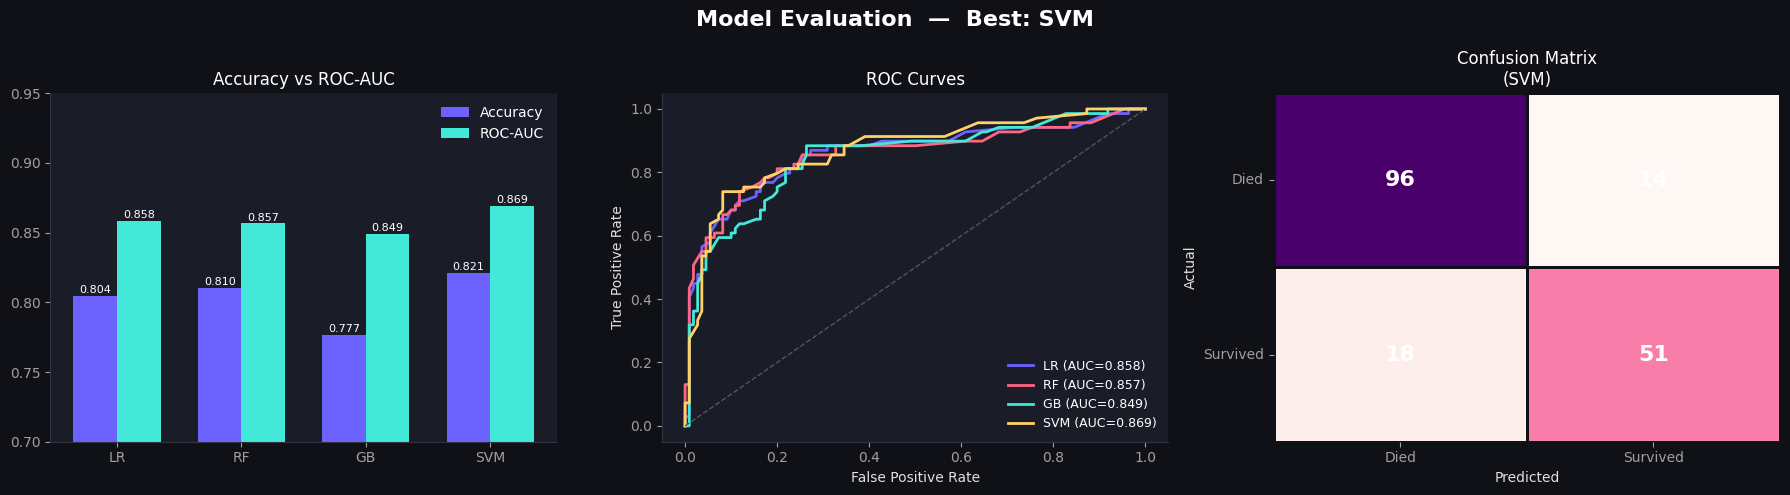

In [13]:
# ─────────────────────────────────────────────
# CELL 7 — Model Evaluation Plots
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Model Evaluation  —  Best: {best_name}',
             fontsize=16, fontweight='bold', color='white')

short_names = ['LR', 'RF', 'GB', 'SVM']
names_list  = list(results.keys())

# A. Accuracy vs ROC-AUC bar chart
ax = axes[0]
x, w = np.arange(4), 0.35
accs = [results[n]['acc'] for n in names_list]
rocs = [results[n]['roc'] for n in names_list]
ax.bar(x - w/2, accs, w, color=ACCENT[0], label='Accuracy',  edgecolor='none')
ax.bar(x + w/2, rocs, w, color=ACCENT[2], label='ROC-AUC',   edgecolor='none')
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylim(0.70, 0.95)
ax.set_title('Accuracy vs ROC-AUC', color='white', fontsize=12)
ax.legend(facecolor='#1a1d27', edgecolor='none', labelcolor='white')
for i, v in enumerate(accs):
    ax.text(i - w/2, v + 0.002, f'{v:.3f}', ha='center', color='white', fontsize=8)
for i, v in enumerate(rocs):
    ax.text(i + w/2, v + 0.002, f'{v:.3f}', ha='center', color='white', fontsize=8)

# B. ROC curves
ax = axes[1]
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    ax.plot(fpr, tpr, color=ACCENT[i], lw=2,
            label=f"{short_names[i]} (AUC={r['roc']:.3f})")
ax.plot([0, 1], [0, 1], '--', color='#555', lw=1)
ax.set_title('ROC Curves', color='white', fontsize=12)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(facecolor='#1a1d27', edgecolor='none', labelcolor='white',
          fontsize=9, loc='lower right')

# C. Confusion matrix of best model
ax = axes[2]
cm = confusion_matrix(y_test, best['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=ax,
            cbar=False, linewidths=2, linecolor='#0f1117',
            annot_kws={'size': 16, 'weight': 'bold', 'color': 'white'})
ax.set_title(f'Confusion Matrix\n({best_name})', color='white', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_xticklabels(['Died', 'Survived'])
ax.set_yticklabels(['Died', 'Survived'], rotation=0)

plt.tight_layout()
plt.show()

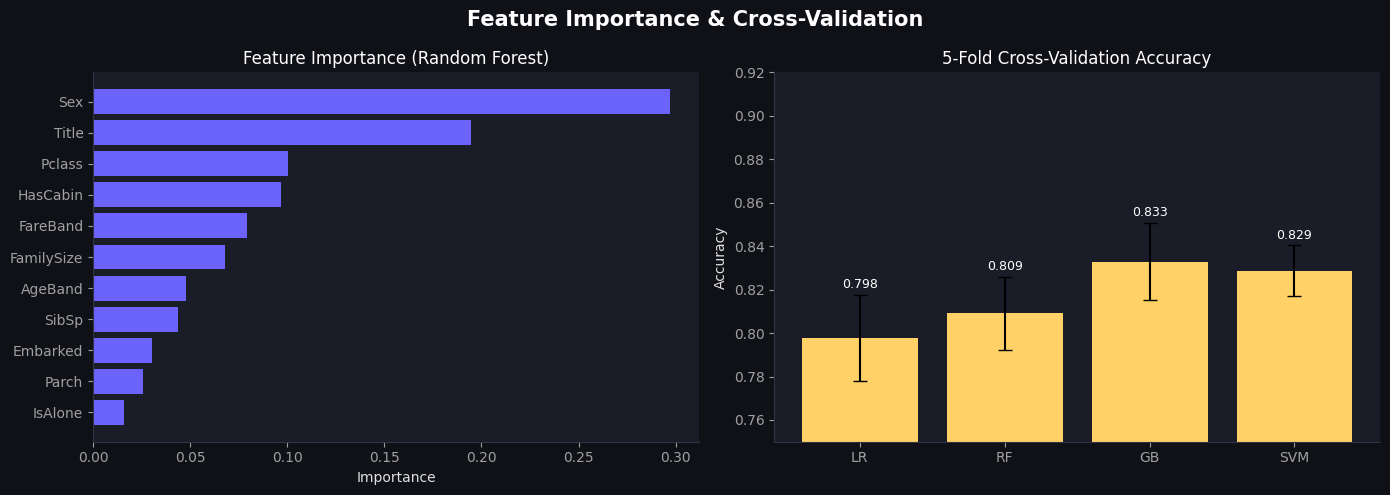

In [14]:
# ─────────────────────────────────────────────
# CELL 8 — Feature Importance & CV Scores
# ─────────────────────────────────────────────
# Pick the better tree-based model for feature importance
tree_name = ('Gradient Boosting'
             if results['Gradient Boosting']['acc'] >= results['Random Forest']['acc']
             else 'Random Forest')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance & Cross-Validation',
             fontsize=15, fontweight='bold', color='white')

# Feature importance
ax = axes[0]
fi  = results[tree_name]['model'].feature_importances_
idx = np.argsort(fi)
ax.barh([FEATURES[i] for i in idx], fi[idx], color=ACCENT[0], edgecolor='none')
ax.set_title(f'Feature Importance ({tree_name})', color='white', fontsize=12)
ax.set_xlabel('Importance')

# 5-Fold CV scores
ax = axes[1]
cv_means = [results[n]['cv_mean'] for n in names_list]
cv_stds  = [results[n]['cv_std']  for n in names_list]
ax.bar(short_names, cv_means, color=ACCENT[3], edgecolor='none',
       yerr=cv_stds, capsize=5,
       error_kw={'color': 'white', 'linewidth': 1.5})
ax.set_ylim(0.75, 0.92)
ax.set_title('5-Fold Cross-Validation Accuracy', color='white', fontsize=12)
ax.set_ylabel('Accuracy')
for i, v in enumerate(cv_means):
    ax.text(i, v + cv_stds[i] + 0.003, f'{v:.3f}',
            ha='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# ─────────────────────────────────────────────
# CELL 9 — Detailed Classification Report
# ─────────────────────────────────────────────
print(f"{'='*50}")
print(f"  Classification Report — {best_name}")
print(f"{'='*50}")
print(classification_report(y_test, best['preds'],
                             target_names=['Died', 'Survived']))
print(f"  Overall Accuracy : {best['acc']:.4f}  ({best['acc']:.2%})")
print(f"  ROC-AUC Score    : {best['roc']:.4f}")
print(f"  5-Fold CV Mean   : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")




  Classification Report — SVM
              precision    recall  f1-score   support

        Died       0.84      0.87      0.86       110
    Survived       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

  Overall Accuracy : 0.8212  (82.12%)
  ROC-AUC Score    : 0.8690
  5-Fold CV Mean   : 0.8287 ± 0.0116


In [16]:
# ─────────────────────────────────────────────
# CELL 10 — Predict on New Passenger
# ─────────────────────────────────────────────
def predict_survival(pclass, sex, age, sibsp, parch, fare,
                     embarked='S', cabin=False):
    """
    Predict survival for a single new passenger.

    Parameters
    ----------
    pclass   : int   — Ticket class (1, 2, or 3)
    sex      : str   — 'male' or 'female'
    age      : float — Passenger age in years
    sibsp    : int   — # siblings / spouses aboard
    parch    : int   — # parents / children aboard
    fare     : float — Ticket fare paid
    embarked : str   — Port: 'S' (Southampton), 'C' (Cherbourg), 'Q' (Queenstown)
    cabin    : bool  — True if cabin number is known
    """
    # Title heuristic
    if sex == 'female':
        title = 'Mrs' if age >= 18 else 'Miss'
    else:
        title = 'Mr' if age >= 18 else 'Master'

    title_map    = {'Master': 0, 'Miss': 1, 'Mr': 2, 'Mrs': 3, 'Rare': 4}
    sex_map      = {'female': 0, 'male': 1}
    embarked_map = {'C': 0, 'Q': 1, 'S': 2}

    age_band  = pd.cut([age],  bins=[0,12,20,40,60,81], labels=[0,1,2,3,4])[0]
    fare_band = pd.cut([fare], bins=[-1,7.91,14.45,31.28,600], labels=[0,1,2,3])[0]

    sample = pd.DataFrame([{
        'Pclass':     pclass,
        'Sex':        sex_map.get(sex, 1),
        'AgeBand':    int(age_band),
        'FareBand':   int(fare_band),
        'Embarked':   embarked_map.get(embarked, 2),
        'FamilySize': sibsp + parch + 1,
        'IsAlone':    int((sibsp + parch) == 0),
        'HasCabin':   int(cabin),
        'Title':      title_map.get(title, 2),
        'SibSp':      sibsp,
        'Parch':      parch,
    }])

    # Use best model (SVM needs scaling)
    model = best['model']
    if best_name in NEEDS_SCALE:
        sample = scaler.transform(sample)

    pred  = model.predict(sample)[0]
    prob  = model.predict_proba(sample)[0][1]

    print(f"\n── Passenger Profile ──────────────────")
    print(f"  Class: {pclass} | Sex: {sex} | Age: {age}")
    print(f"  Fare: £{fare} | Family: {sibsp+parch} | Cabin: {cabin}")
    print(f"  Embarked: {embarked}")
    print(f"── Prediction ({best_name}) ──────────")
    print(f"  Outcome       : {' SURVIVED' if pred == 1 else ' DID NOT SURVIVE'}")
    print(f"  Survival Prob : {prob:.2%}")
    print(f"───────────────────────────────────────")
    return pred, prob

# ── Example predictions ──
predict_survival(pclass=1, sex='female', age=29, sibsp=0, parch=0,
                 fare=211, embarked='S', cabin=True)

predict_survival(pclass=3, sex='male',   age=22, sibsp=1, parch=0,
                 fare=7.25, embarked='S', cabin=False)

predict_survival(pclass=2, sex='female', age=8,  sibsp=0, parch=1,
                 fare=26, embarked='C', cabin=False)

print("\n All done! Modify the predict_survival() call above to test your own passengers.")


── Passenger Profile ──────────────────
  Class: 1 | Sex: female | Age: 29
  Fare: £211 | Family: 0 | Cabin: True
  Embarked: S
── Prediction (SVM) ──────────
  Outcome       :  SURVIVED
  Survival Prob : 87.50%
───────────────────────────────────────

── Passenger Profile ──────────────────
  Class: 3 | Sex: male | Age: 22
  Fare: £7.25 | Family: 1 | Cabin: False
  Embarked: S
── Prediction (SVM) ──────────
  Outcome       :  DID NOT SURVIVE
  Survival Prob : 11.33%
───────────────────────────────────────

── Passenger Profile ──────────────────
  Class: 2 | Sex: female | Age: 8
  Fare: £26 | Family: 1 | Cabin: False
  Embarked: C
── Prediction (SVM) ──────────
  Outcome       :  SURVIVED
  Survival Prob : 89.56%
───────────────────────────────────────

 All done! Modify the predict_survival() call above to test your own passengers.
